In [1]:
import os
import requests
import numpy as np
import matplotlib.pyplot as plt

from io import BytesIO
from PIL import Image

In [2]:
# URL da imagem armazenada na pasta input do repositório
url_imagem = (
    "https://raw.githubusercontent.com/"
    "lianeheidemann/atividades-processamento-de-imagens/"
    "main/atividade/atividade-1/input/morango.jpg"
)

# Baixar a imagem do GitHub
resposta = requests.get(url_imagem)
resposta.raise_for_status()

# Abrir a imagem e converter para tons de cinza
img = np.array(
    Image.open(BytesIO(resposta.content)).convert("L")
)

# Criar uma pasta para salvar os resultados no Colab
pasta_saida = "/content/output"
os.makedirs(pasta_saida, exist_ok=True)

print("Imagem carregada corretamente.")

Imagem carregada corretamente.


In [3]:
#Função de quantização

def quantizar(im, bits):
    niveis = 2 ** bits
    passo = 256 / niveis

    # Quantizar as intensidades
    q = np.floor(im / passo) * passo

    # Reescalar para o intervalo de 0 a 255
    q = q * (255 / (256 - passo))

    return q.astype(np.uint8)

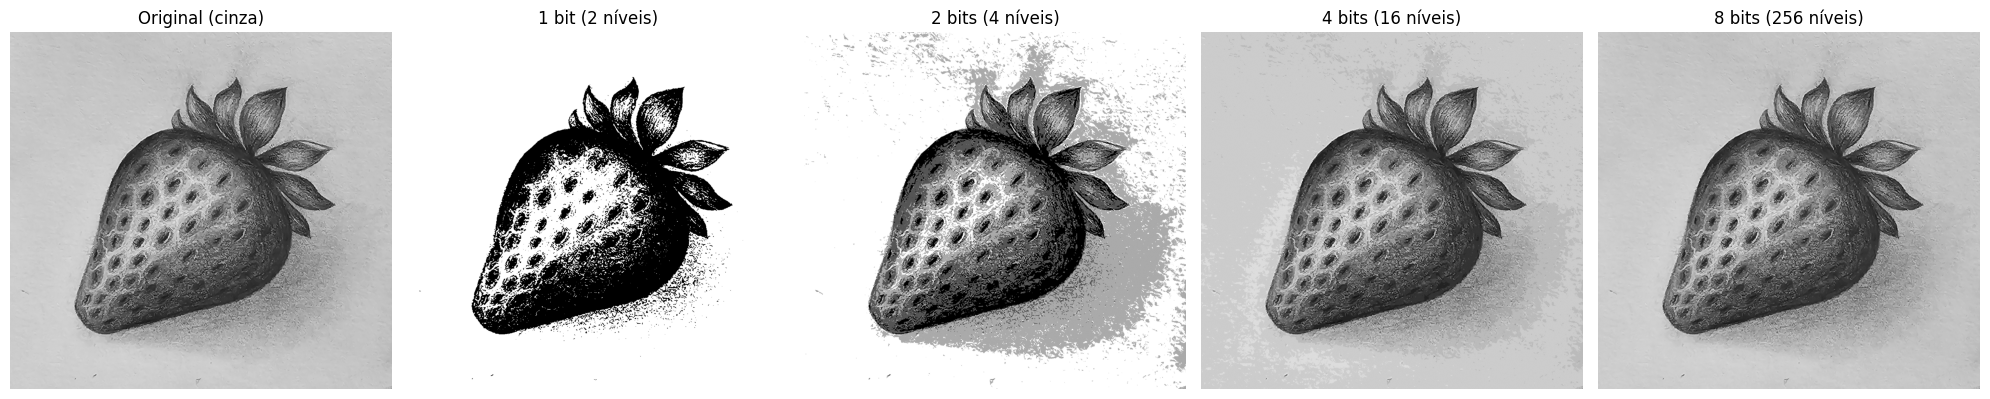

In [4]:
# Montar a figura

bits_list = [1, 2, 4, 8]

fig, axes = plt.subplots(1, 5, figsize=(20, 5))

axes[0].imshow(img, cmap="gray", vmin=0, vmax=255)
axes[0].set_title("Original (cinza)")
axes[0].axis("off")

for ax, bits in zip(axes[1:], bits_list):
    imagem_quantizada = quantizar(img, bits)

    ax.imshow(
        imagem_quantizada,
        cmap="gray",
        vmin=0,
        vmax=255
    )

    ax.set_title(
        f'{bits} bit{"s" if bits > 1 else ""} '
        f'({2 ** bits} níveis)'
    )
    ax.axis("off")

plt.tight_layout()

# Salvar a figura no ambiente do Colab
fig.savefig(
    os.path.join(pasta_saida, "quantizacao.png"),
    dpi=150,
    bbox_inches="tight"
)

plt.show()

**Pergunta: O que acontece com os detalhes e com as transições de intensidade da imagem à medida que reduzimos o número de bits?**

À medida que reduzimos o número de bits, diminuímos a quantidade de tons de cinza disponíveis:

- 8 bits: 256 níveis — imagem idêntica à original, com todo o gradiente suave do desenho a lápis preservado, incluindo a textura do papel e o sombreado sutil do morango.
- 4 bits: 16 níveis — visualmente quase indistinguível da original; o sombreado do morango e o fundo continuam suaves, sem degraus perceptíveis.
- 2 bits: 4 níveis — o fundo, antes uniforme, passa a exibir um forte ruído "granulado" (speckling), pois os poucos níveis disponíveis não conseguem representar bem a textura sutil do papel. O corpo do morango perde parte do sombreado, ficando com regiões de cinza mais uniformes e bordas mais duras.
- 1 bit: apenas preto e branco — o morango vira praticamente uma silhueta binária; os pontinhos (sementes) só continuam visíveis porque formam um forte contraste local, mas todo o sombreado desaparece. O fundo, que era quase branco liso, agora mostra manchas pretas espalhadas nas áreas de textura mais escura do papel.

Em resumo: como o desenho original já tem baixo contraste e transições suaves (sombreado a lápis e textura de papel), a perda começa a ficar visível já em 2 bits, principalmente como ruído no fundo, e se torna extrema em 1 bit, onde a imagem se reduz a uma silhueta de alto contraste. Já em 4 e 8 bits o resultado é praticamente igual ao original, pois 16 níveis de cinza já são suficientes para reproduzir esse tipo de sombreado suave.